In [14]:
# Filtering out the warnings

import warnings

warnings.filterwarnings('ignore')

In [15]:
# Importing the required libraries

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm

In [16]:
# Mounting google drive

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Reading the first 10 rows to have a look at the values

In [17]:
df = pd.read_csv("/content/drive/MyDrive/day.csv")
df.head(10)

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,01-01-2018,1,0,1,0,1,1,2,14.110847,18.18125,80.5833,10.749882,331,654,985
1,2,02-01-2018,1,0,1,0,2,1,2,14.902598,17.68695,69.6087,16.652113,131,670,801
2,3,03-01-2018,1,0,1,0,3,1,1,8.050924,9.47025,43.7273,16.636703,120,1229,1349
3,4,04-01-2018,1,0,1,0,4,1,1,8.200000,10.60610,59.0435,10.739832,108,1454,1562
4,5,05-01-2018,1,0,1,0,5,1,1,9.305237,11.46350,43.6957,12.522300,82,1518,1600
5,6,06-01-2018,1,0,1,0,6,0,1,8.378268,11.66045,51.8261,6.000868,88,1518,1606
6,7,07-01-2018,1,0,1,0,0,0,2,8.057402,10.44195,49.8696,11.304642,148,1362,1510
7,8,08-01-2018,1,0,1,0,1,1,2,6.765000,8.11270,53.5833,17.875868,68,891,959
8,9,09-01-2018,1,0,1,0,2,1,1,5.671653,5.80875,43.4167,24.250650,54,768,822
9,10,10-01-2018,1,0,1,0,3,1,1,6.184153,7.54440,48.2917,14.958889,41,1280,1321


Checking the total numbers of rows and columns

In [18]:
df.shape

(730, 16)

Checking the column description and datatypes

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 730 entries, 0 to 729
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     730 non-null    int64  
 1   dteday      730 non-null    object 
 2   season      730 non-null    int64  
 3   yr          730 non-null    int64  
 4   mnth        730 non-null    int64  
 5   holiday     730 non-null    int64  
 6   weekday     730 non-null    int64  
 7   workingday  730 non-null    int64  
 8   weathersit  730 non-null    int64  
 9   temp        730 non-null    float64
 10  atemp       730 non-null    float64
 11  hum         730 non-null    float64
 12  windspeed   730 non-null    float64
 13  casual      730 non-null    int64  
 14  registered  730 non-null    int64  
 15  cnt         730 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.4+ KB


In [20]:
df.describe()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000
mean,365.500000,2.498630,0.500000,6.526027,0.028767,2.995890,0.690411,1.394521,20.319259,23.726322,62.765175,12.763620,849.249315,3658.757534,4508.006849
std,210.877136,1.110184,0.500343,3.450215,0.167266,2.000339,0.462641,0.544807,7.506729,8.150308,14.237589,5.195841,686.479875,1559.758728,1936.011647
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,2.424346,3.953480,0.000000,1.500244,2.000000,20.000000,22.000000
25%,183.250000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,13.811885,16.889713,52.000000,9.041650,316.250000,2502.250000,3169.750000
50%,365.500000,3.000000,0.500000,7.000000,0.000000,3.000000,1.000000,1.000000,20.465826,24.368225,62.625000,12.125325,717.000000,3664.500000,4548.500000
75%,547.750000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,26.880615,30.445775,72.989575,15.625589,1096.500000,4783.250000,5966.000000
max,730.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,35.328347,42.044800,97.250000,34.000021,3410.000000,6946.000000,8714.000000


We can use pairplot as below to find out relationships

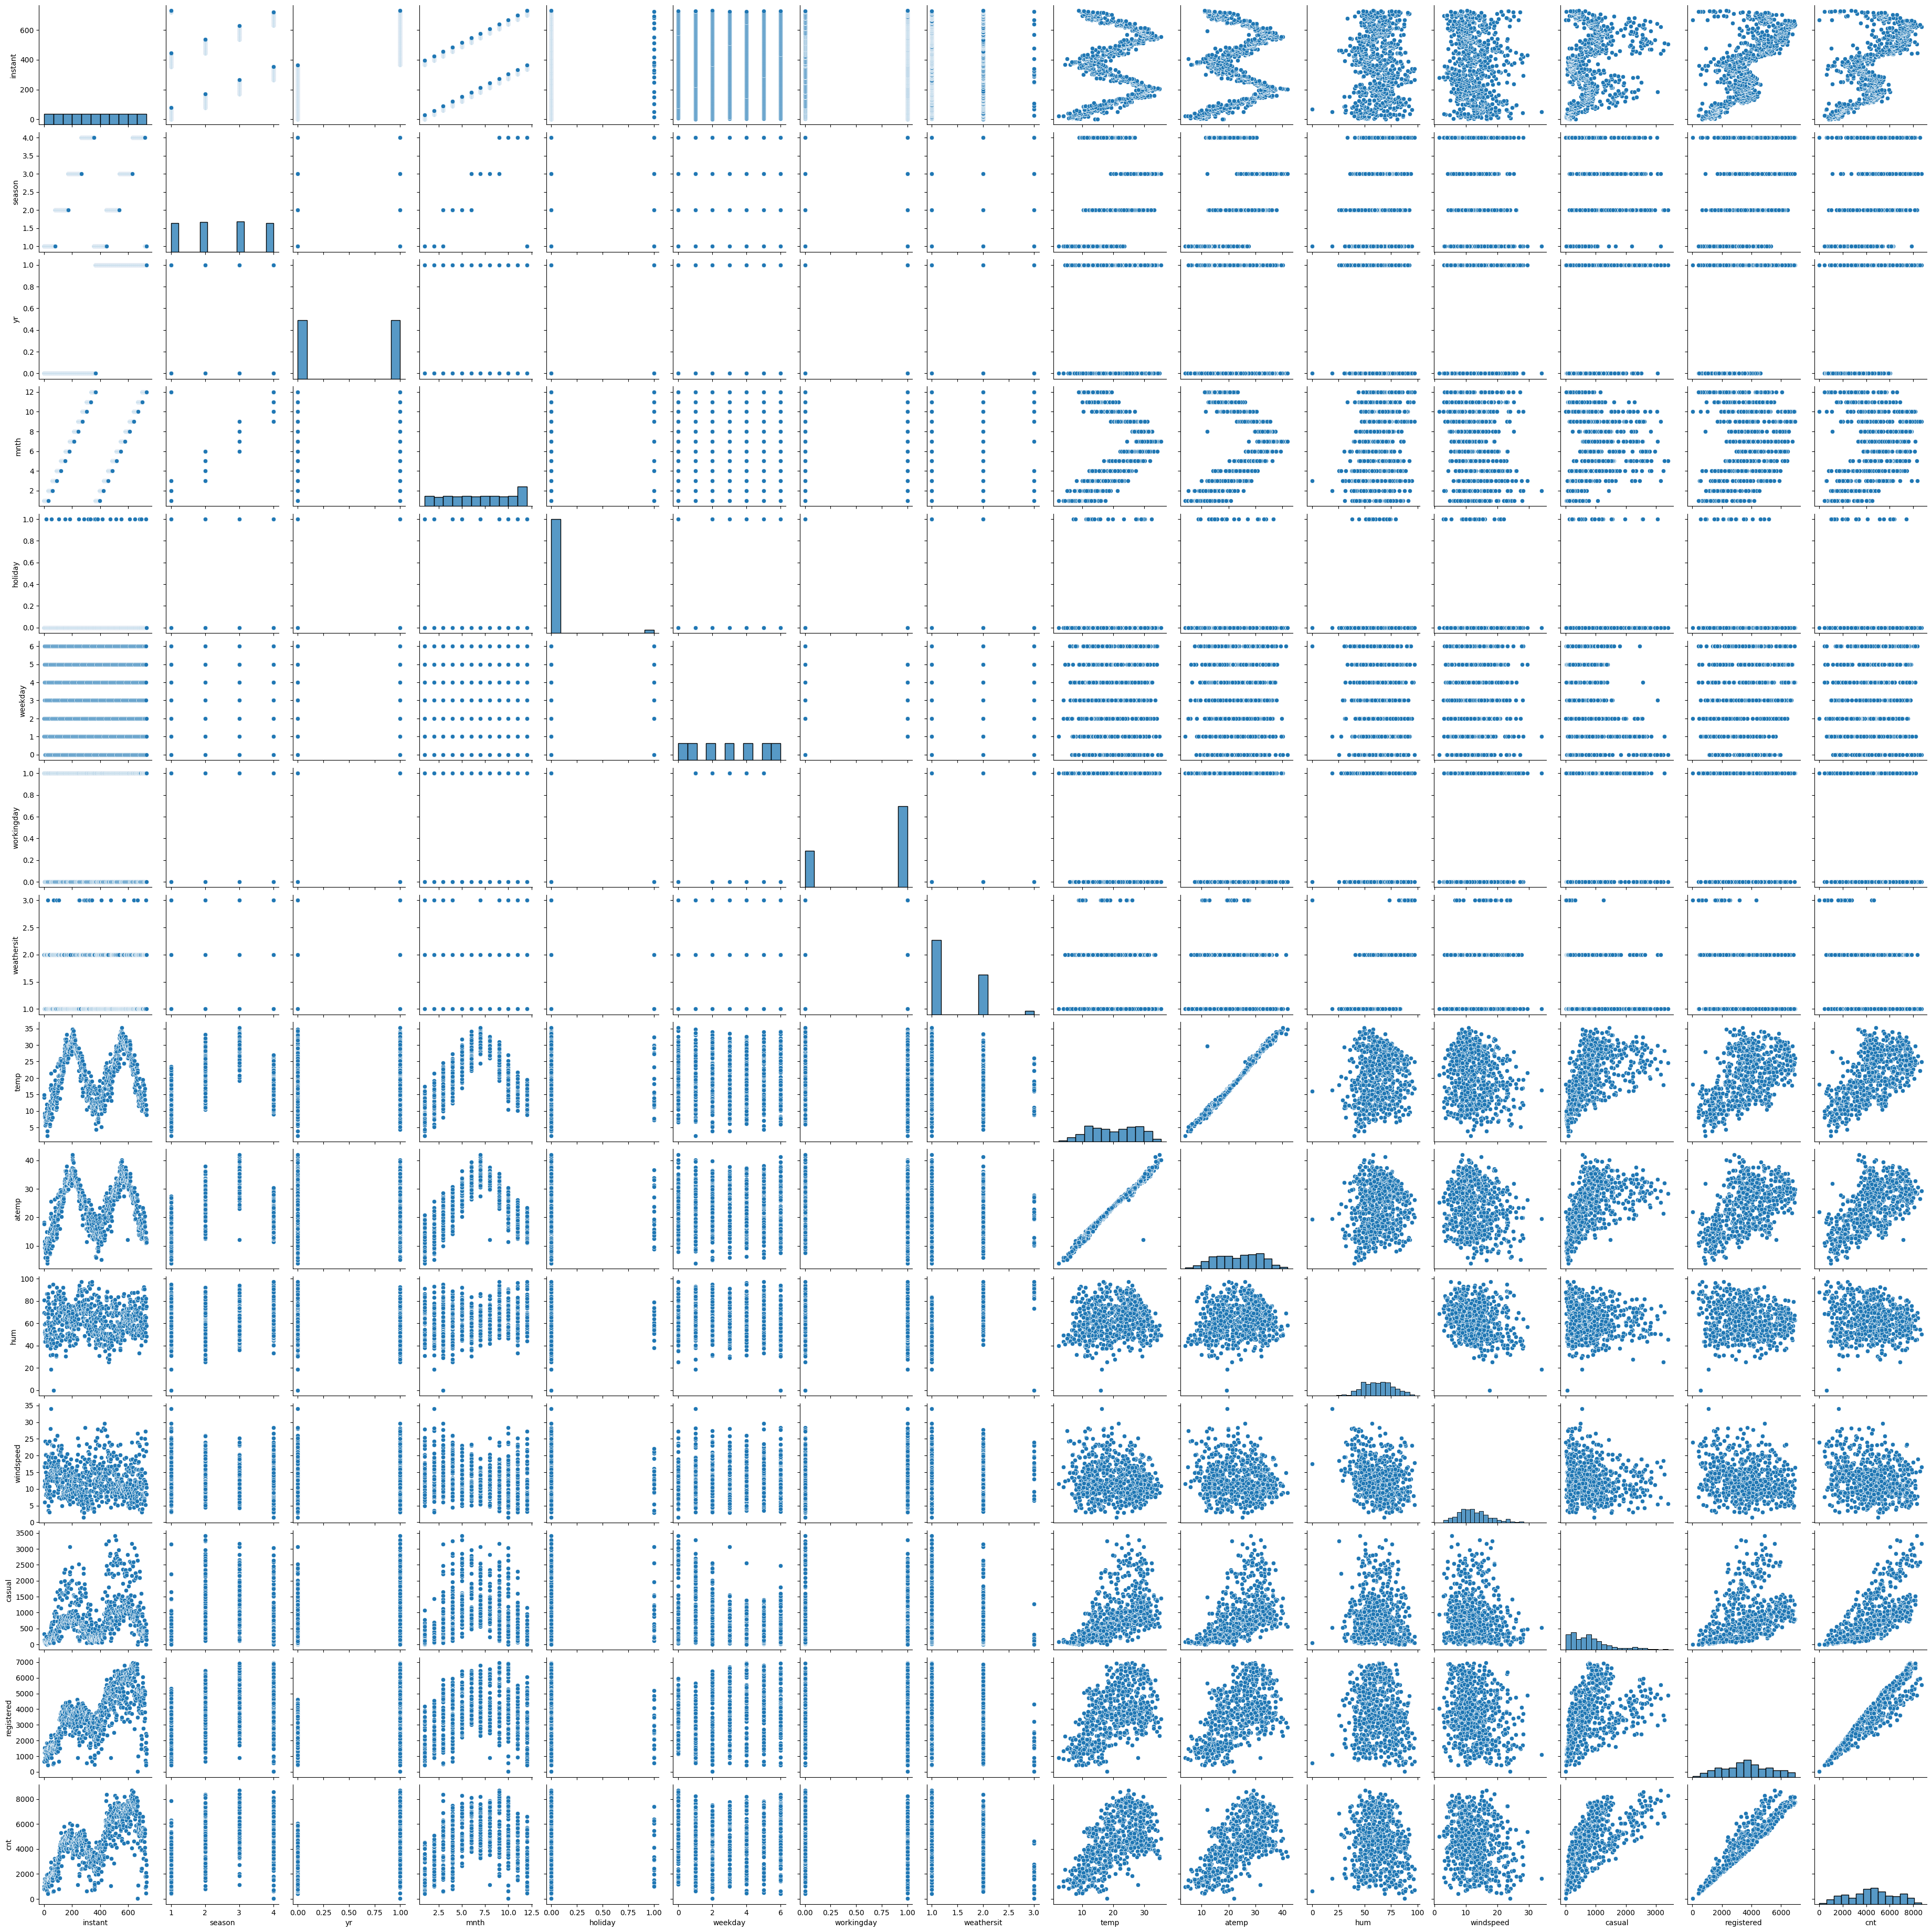

In [21]:
sns.pairplot(df)

From the above we can determine that cnt, casual and registered are similar,
we can safely remove registered and casual

In [22]:
df.columns

Index(['instant', 'dteday', 'season', 'yr', 'mnth', 'holiday', 'weekday',
       'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed',
       'casual', 'registered', 'cnt'],
      dtype='object')

In [23]:
df.drop(['casual', 'registered', 'dteday'], axis = 1, inplace = True)

In [24]:
df.columns

Index(['instant', 'season', 'yr', 'mnth', 'holiday', 'weekday', 'workingday',
       'weathersit', 'temp', 'atemp', 'hum', 'windspeed', 'cnt'],
      dtype='object')

<Axes: xlabel='yr', ylabel='cnt'>

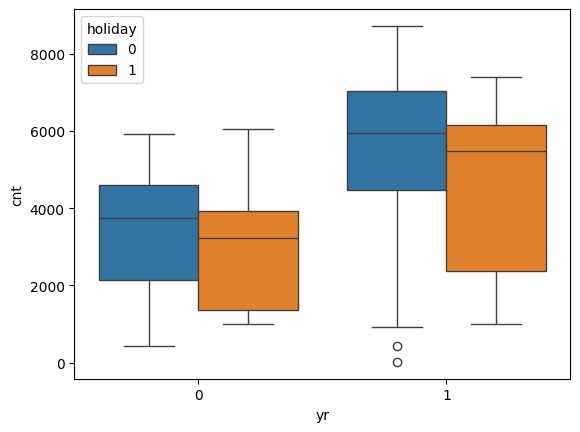

In [25]:
sns.boxplot(data = df, x = 'yr', y = 'cnt', hue = 'holiday')

From the above boxplot we can determine the following:
1. 2019 has higher usage as compared to 2018
2. Mean of cnt during holiday is greater for both years as compared to non-holidays


<Axes: xlabel='season', ylabel='cnt'>

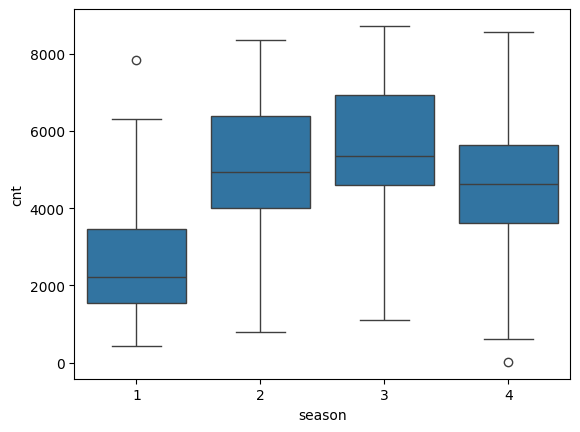

In [26]:
sns.boxplot(data = df, x = 'season', y = 'cnt')

From the above boxplot, following can be determined:
1. Spring season has least median of rental counts
2. Its followed by summer, followed by winter
3. Fall season has the highest median of rental counts

<Axes: xlabel='weathersit', ylabel='cnt'>

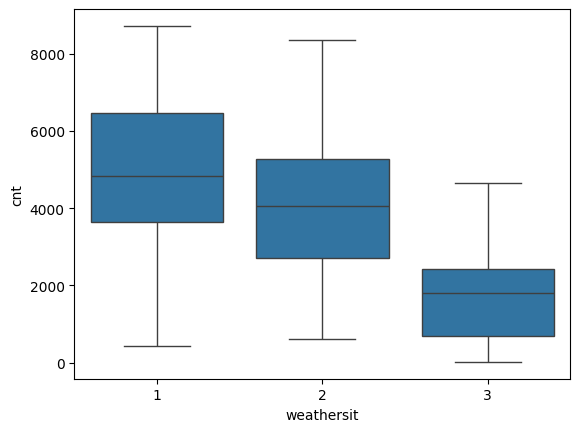

In [27]:
sns.boxplot(data = df, x = 'weathersit', y = 'cnt')

From the above we can determine that:
1. Clear weather has the highest median rental counts

<Axes: xlabel='mnth', ylabel='cnt'>

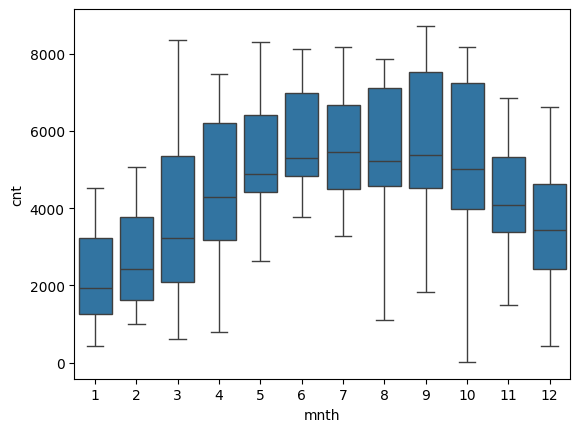

In [28]:
sns.boxplot(data = df, x = 'mnth', y = 'cnt')

In [29]:
categorical_cols = ['season', 'yr', 'mnth', 'holiday', 'weekday', 'workingday', 'weathersit']
numerical_cols = ['atemp', 'hum', 'windspeed']

From the above we identify the numerical and catergorical columns

In [30]:
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

We create dummies for categorical columns

In [31]:
df.columns

Index(['instant', 'temp', 'atemp', 'hum', 'windspeed', 'cnt', 'season_2',
       'season_3', 'season_4', 'yr_1', 'mnth_2', 'mnth_3', 'mnth_4', 'mnth_5',
       'mnth_6', 'mnth_7', 'mnth_8', 'mnth_9', 'mnth_10', 'mnth_11', 'mnth_12',
       'holiday_1', 'weekday_1', 'weekday_2', 'weekday_3', 'weekday_4',
       'weekday_5', 'weekday_6', 'workingday_1', 'weathersit_2',
       'weathersit_3'],
      dtype='object')

In [32]:
scaler = StandardScaler()

Initialising standard scaler

In [33]:
df_train, df_test = train_test_split(df, test_size=0.2, random_state=101)

In [34]:
y_train = df_train.pop('cnt')
x_train = df_train

In [35]:
y_test = df_test.pop('cnt')
x_test = df_test

In [36]:
x_train.drop(['temp', 'instant'], axis = 1, inplace = True)

In [37]:
x_test.drop(['temp', 'instant'], axis = 1, inplace = True)

In [38]:
x_train.corr()

,atemp,hum,windspeed,season_2,season_3,season_4,yr_1,mnth_2,mnth_3,mnth_4,...,holiday_1,weekday_1,weekday_2,weekday_3,weekday_4,weekday_5,weekday_6,workingday_1,weathersit_2,weathersit_3
atemp,1.000000,0.133987,-0.192795,0.161754,0.662268,-0.214284,0.047530,-0.308560,-0.174836,-0.051725,...,-0.036475,0.008802,-0.027533,-0.046077,0.033883,0.027092,0.027891,0.008126,-0.103497,-0.073447
hum,0.133987,1.000000,-0.258606,-0.011711,0.040329,0.175067,-0.105641,-0.162219,-0.080371,-0.086025,...,-0.031435,0.027184,-0.009221,0.001656,-0.005167,0.018430,-0.011302,0.035262,0.485245,0.315490
windspeed,-0.192795,-0.258606,1.000000,0.106631,-0.156469,-0.130252,-0.010364,0.135402,0.104773,0.201186,...,0.012014,0.044229,0.019379,-0.006969,-0.040404,-0.006344,-0.018562,0.004128,-0.055326,0.125972
season_2,0.161754,-0.011711,0.106631,1.000000,-0.347159,-0.322462,-0.015793,-0.173145,0.051483,0.511316,...,-0.001978,0.006363,0.000645,-0.021946,0.011730,0.003490,-0.007648,0.005704,0.067006,-0.050103
season_3,0.662268,0.040329,-0.156469,-0.347159,1.000000,-0.326821,-0.011868,-0.175486,-0.185450,-0.177508,...,-0.051743,0.034885,-0.004224,-0.026401,-0.004224,0.009702,0.009702,0.021915,-0.099459,-0.027836
season_4,-0.214284,0.175067,-0.130252,-0.322462,-0.326821,1.000000,0.020534,-0.163002,-0.172257,-0.164880,...,0.006800,-0.029573,-0.023178,0.009952,0.022552,0.025337,0.002361,0.006019,0.036977,0.106072
yr_1,0.047530,-0.105641,-0.010364,-0.015793,-0.011868,0.020534,1.000000,0.016858,0.021908,-0.002050,...,0.019830,-0.022326,0.016482,0.007378,-0.012511,0.002029,-0.007683,-0.021445,0.017077,-0.064090
mnth_2,-0.308560,-0.162219,0.135402,-0.173145,-0.175486,-0.163002,0.016858,1.000000,-0.092493,-0.088532,...,0.027468,-0.031574,0.001399,0.031874,0.001399,-0.032856,0.002842,-0.035418,-0.019457,-0.011093
mnth_3,-0.174836,-0.080371,0.104773,0.051483,-0.185450,-0.172257,0.021908,-0.092493,1.000000,-0.093559,...,-0.052472,-0.025347,-0.028123,0.018642,0.022777,-0.009692,-0.009692,-0.000804,0.037168,-0.052472
mnth_4,-0.051725,-0.086025,0.201186,0.511316,-0.177508,-0.164880,-0.002050,-0.088532,-0.093559,1.000000,...,0.026159,0.037235,0.016388,-0.044185,-0.001205,0.000242,-0.017437,0.009632,0.016180,0.026159


In [39]:
x_train.columns

Index(['atemp', 'hum', 'windspeed', 'season_2', 'season_3', 'season_4', 'yr_1',
       'mnth_2', 'mnth_3', 'mnth_4', 'mnth_5', 'mnth_6', 'mnth_7', 'mnth_8',
       'mnth_9', 'mnth_10', 'mnth_11', 'mnth_12', 'holiday_1', 'weekday_1',
       'weekday_2', 'weekday_3', 'weekday_4', 'weekday_5', 'weekday_6',
       'workingday_1', 'weathersit_2', 'weathersit_3'],
      dtype='object')

In [40]:
x_test.columns

Index(['atemp', 'hum', 'windspeed', 'season_2', 'season_3', 'season_4', 'yr_1',
       'mnth_2', 'mnth_3', 'mnth_4', 'mnth_5', 'mnth_6', 'mnth_7', 'mnth_8',
       'mnth_9', 'mnth_10', 'mnth_11', 'mnth_12', 'holiday_1', 'weekday_1',
       'weekday_2', 'weekday_3', 'weekday_4', 'weekday_5', 'weekday_6',
       'workingday_1', 'weathersit_2', 'weathersit_3'],
      dtype='object')

In [41]:
x_train[numerical_cols] = scaler.fit_transform(x_train[numerical_cols])
x_test[numerical_cols] = scaler.transform(x_test[numerical_cols])

In [42]:
x_train[numerical_cols].head()

,atemp,hum,windspeed
23,-2.188390,-0.950430,-0.377030
527,0.751671,1.471677,0.344584
257,0.480885,0.591265,1.071127
18,-1.082727,0.822221,0.264626
148,0.859945,1.368275,0.336779


In [43]:
x_test[numerical_cols].head()

,atemp,hum,windspeed
299,-0.111024,1.326915,0.129150
723,-1.106967,0.772898,-0.243582
647,0.171353,0.035830,0.001530
520,0.310715,-0.088255,0.280774
114,0.608479,1.069881,-0.030407


<Axes: >

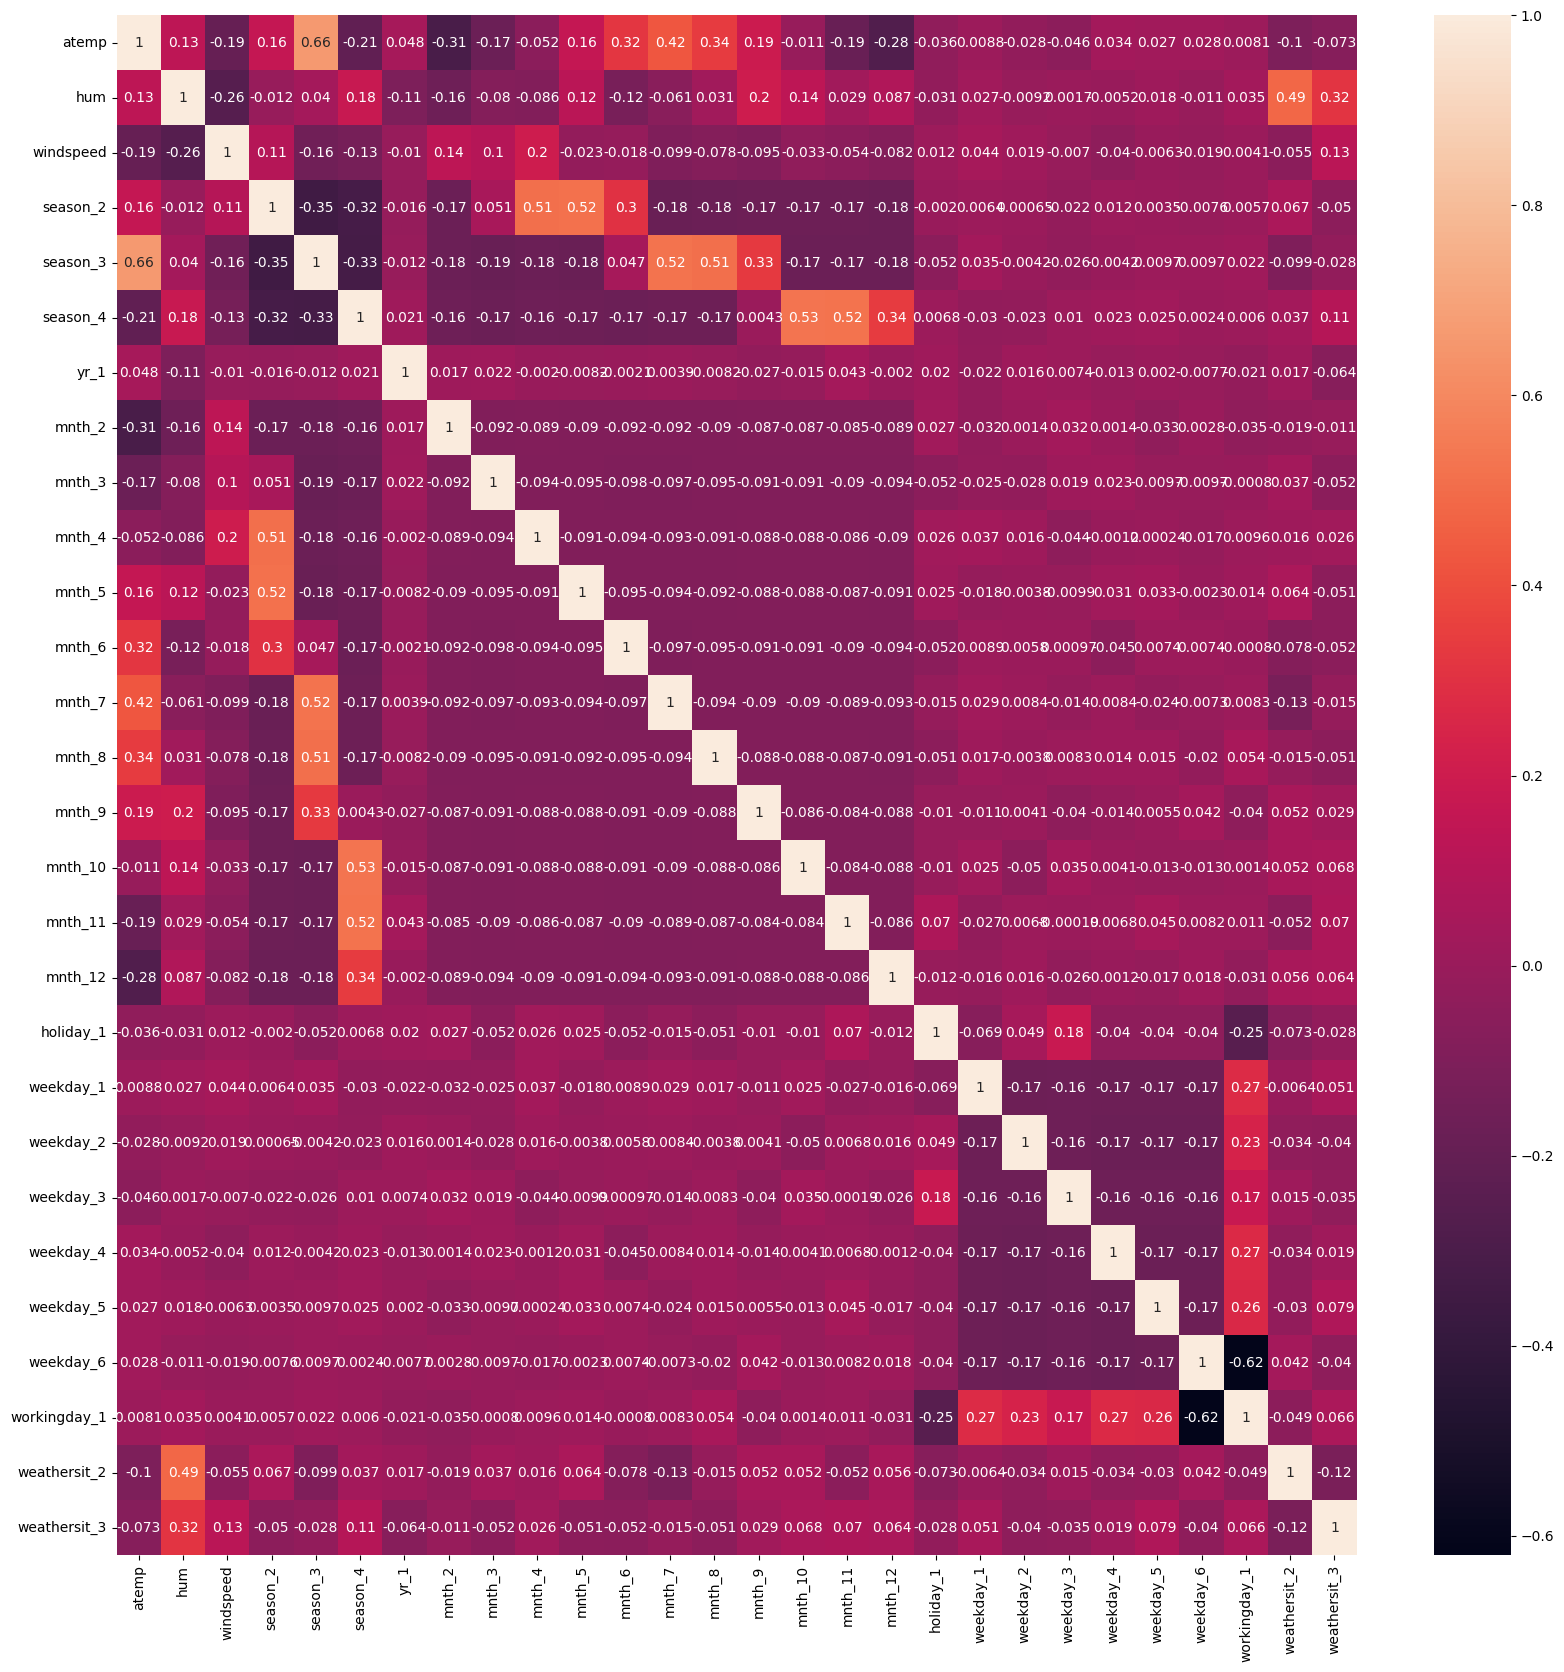

In [44]:
plt.figure(figsize=(20, 20))
sns.heatmap(x_train.corr(), annot=True)


In [45]:
x_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 584 entries, 23 to 523
Data columns (total 28 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   atemp         584 non-null    float64
 1   hum           584 non-null    float64
 2   windspeed     584 non-null    float64
 3   season_2      584 non-null    bool   
 4   season_3      584 non-null    bool   
 5   season_4      584 non-null    bool   
 6   yr_1          584 non-null    bool   
 7   mnth_2        584 non-null    bool   
 8   mnth_3        584 non-null    bool   
 9   mnth_4        584 non-null    bool   
 10  mnth_5        584 non-null    bool   
 11  mnth_6        584 non-null    bool   
 12  mnth_7        584 non-null    bool   
 13  mnth_8        584 non-null    bool   
 14  mnth_9        584 non-null    bool   
 15  mnth_10       584 non-null    bool   
 16  mnth_11       584 non-null    bool   
 17  mnth_12       584 non-null    bool   
 18  holiday_1     584 non-null    bool

In [46]:
x_train = x_train.astype(int)
x_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 584 entries, 23 to 523
Data columns (total 28 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   atemp         584 non-null    int64
 1   hum           584 non-null    int64
 2   windspeed     584 non-null    int64
 3   season_2      584 non-null    int64
 4   season_3      584 non-null    int64
 5   season_4      584 non-null    int64
 6   yr_1          584 non-null    int64
 7   mnth_2        584 non-null    int64
 8   mnth_3        584 non-null    int64
 9   mnth_4        584 non-null    int64
 10  mnth_5        584 non-null    int64
 11  mnth_6        584 non-null    int64
 12  mnth_7        584 non-null    int64
 13  mnth_8        584 non-null    int64
 14  mnth_9        584 non-null    int64
 15  mnth_10       584 non-null    int64
 16  mnth_11       584 non-null    int64
 17  mnth_12       584 non-null    int64
 18  holiday_1     584 non-null    int64
 19  weekday_1     584 non-null    int

In [47]:
y_train.info()

<class 'pandas.core.series.Series'>
Index: 584 entries, 23 to 523
Series name: cnt
Non-Null Count  Dtype
--------------  -----
584 non-null    int64
dtypes: int64(1)
memory usage: 9.1 KB


In [48]:
y_train = y_train.astype(int)
y_train.info()

<class 'pandas.core.series.Series'>
Index: 584 entries, 23 to 523
Series name: cnt
Non-Null Count  Dtype
--------------  -----
584 non-null    int64
dtypes: int64(1)
memory usage: 9.1 KB


In [49]:
x_train.head()

,atemp,hum,windspeed,season_2,season_3,season_4,yr_1,mnth_2,mnth_3,mnth_4,...,holiday_1,weekday_1,weekday_2,weekday_3,weekday_4,weekday_5,weekday_6,workingday_1,weathersit_2,weathersit_3
23,-2,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,1,0,0
527,0,1,0,1,0,0,1,0,0,0,...,0,0,0,1,0,0,0,1,1,0
257,0,0,1,0,1,0,0,0,0,0,...,0,0,0,0,0,0,1,0,1,0
18,-1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,1,1,0
148,0,1,0,1,0,0,0,0,0,0,...,0,0,1,0,0,0,0,1,0,0


In [50]:
x_train = x_train.reset_index(drop=True)


In [51]:
y_train = y_train.reset_index(drop=True)

In [52]:
x_train.head()

,atemp,hum,windspeed,season_2,season_3,season_4,yr_1,mnth_2,mnth_3,mnth_4,...,holiday_1,weekday_1,weekday_2,weekday_3,weekday_4,weekday_5,weekday_6,workingday_1,weathersit_2,weathersit_3
0,-2,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,1,0,0
1,0,1,0,1,0,0,1,0,0,0,...,0,0,0,1,0,0,0,1,1,0
2,0,0,1,0,1,0,0,0,0,0,...,0,0,0,0,0,0,1,0,1,0
3,-1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,1,1,0
4,0,1,0,1,0,0,0,0,0,0,...,0,0,1,0,0,0,0,1,0,0


In [53]:
y_train.head()

,cnt
0,1416
1,4972
2,3659
3,1650
4,4788


In [54]:
x_train = sm.add_constant(x_train)

In [55]:
lr = sm.OLS(y_train, x_train).fit()

In [56]:
print(lr.summary())

                            OLS Regression Results                            
Dep. Variable:                    cnt   R-squared:                       0.824
Model:                            OLS   Adj. R-squared:                  0.816
Method:                 Least Squares   F-statistic:                     93.10
Date:                Fri, 19 Jun 2026   Prob (F-statistic):          2.14e-189
Time:                        17:54:42   Log-Likelihood:                -4736.7
No. Observations:                 584   AIC:                             9531.
Df Residuals:                     555   BIC:                             9658.
Df Model:                          28                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const         1936.7486    171.062     11.322   

In [57]:
x_train.drop('weekday_6', axis=1, inplace=True)
x_test.drop('weekday_6', axis=1, inplace=True)

In [58]:
x_train = sm.add_constant(x_train)

In [59]:
lr = sm.OLS(y_train, x_train).fit()
print(lr.summary())

                            OLS Regression Results                            
Dep. Variable:                    cnt   R-squared:                       0.824
Model:                            OLS   Adj. R-squared:                  0.816
Method:                 Least Squares   F-statistic:                     96.72
Date:                Fri, 19 Jun 2026   Prob (F-statistic):          2.16e-190
Time:                        17:54:43   Log-Likelihood:                -4736.7
No. Observations:                 584   AIC:                             9529.
Df Residuals:                     556   BIC:                             9652.
Df Model:                          27                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const         1944.0450    155.162     12.529   

In [60]:
x_train.drop(['mnth_11'], axis=1, inplace=True)
x_test.drop(['mnth_11'], axis=1, inplace=True)


In [61]:
x_train = sm.add_constant(x_train)
lr = sm.OLS(y_train, x_train).fit()
print(lr.summary())

                            OLS Regression Results                            
Dep. Variable:                    cnt   R-squared:                       0.824
Model:                            OLS   Adj. R-squared:                  0.816
Method:                 Least Squares   F-statistic:                     100.6
Date:                Fri, 19 Jun 2026   Prob (F-statistic):          2.19e-191
Time:                        17:54:43   Log-Likelihood:                -4736.7
No. Observations:                 584   AIC:                             9527.
Df Residuals:                     557   BIC:                             9645.
Df Model:                          26                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const         1956.8849    144.929     13.502   

In [62]:
x_train.drop(['mnth_12'], axis=1, inplace=True)
x_test.drop(['mnth_12'], axis=1, inplace=True)

In [63]:
x_train = sm.add_constant(x_train)
lr = sm.OLS(y_train, x_train).fit()
print(lr.summary())

                            OLS Regression Results                            
Dep. Variable:                    cnt   R-squared:                       0.824
Model:                            OLS   Adj. R-squared:                  0.817
Method:                 Least Squares   F-statistic:                     104.8
Date:                Fri, 19 Jun 2026   Prob (F-statistic):          2.13e-192
Time:                        17:54:43   Log-Likelihood:                -4736.7
No. Observations:                 584   AIC:                             9525.
Df Residuals:                     558   BIC:                             9639.
Df Model:                          25                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const         1960.3640    140.476     13.955   

In [64]:
x_train.drop(['weekday_2'], axis=1, inplace=True)
x_test.drop(['weekday_2'], axis=1, inplace=True)

In [65]:
x_train = sm.add_constant(x_train)
lr = sm.OLS(y_train, x_train).fit()
print(lr.summary())

                            OLS Regression Results                            
Dep. Variable:                    cnt   R-squared:                       0.824
Model:                            OLS   Adj. R-squared:                  0.817
Method:                 Least Squares   F-statistic:                     109.2
Date:                Fri, 19 Jun 2026   Prob (F-statistic):          3.09e-193
Time:                        17:54:43   Log-Likelihood:                -4737.2
No. Observations:                 584   AIC:                             9524.
Df Residuals:                     559   BIC:                             9634.
Df Model:                          24                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const         1962.2685    140.444     13.972   

In [66]:
x_train.drop(['weekday_3'], axis=1, inplace=True)
x_test.drop(['weekday_3'], axis=1, inplace=True)

In [67]:
x_train = sm.add_constant(x_train)
lr = sm.OLS(y_train, x_train).fit()
print(lr.summary())

                            OLS Regression Results                            
Dep. Variable:                    cnt   R-squared:                       0.823
Model:                            OLS   Adj. R-squared:                  0.816
Method:                 Least Squares   F-statistic:                     113.4
Date:                Fri, 19 Jun 2026   Prob (F-statistic):          1.28e-193
Time:                        17:54:43   Log-Likelihood:                -4738.7
No. Observations:                 584   AIC:                             9525.
Df Residuals:                     560   BIC:                             9630.
Df Model:                          23                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const         1950.9536    140.547     13.881   

In [68]:
x_train.drop(['weekday_1'], axis=1, inplace=True)
x_test.drop(['weekday_1'], axis=1, inplace=True)

In [69]:
x_train = sm.add_constant(x_train)
lr = sm.OLS(y_train, x_train).fit()
print(lr.summary())

                            OLS Regression Results                            
Dep. Variable:                    cnt   R-squared:                       0.823
Model:                            OLS   Adj. R-squared:                  0.816
Method:                 Least Squares   F-statistic:                     118.6
Date:                Fri, 19 Jun 2026   Prob (F-statistic):          1.54e-194
Time:                        17:54:43   Log-Likelihood:                -4739.0
No. Observations:                 584   AIC:                             9524.
Df Residuals:                     561   BIC:                             9625.
Df Model:                          22                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const         1954.9659    140.392     13.925   

In [70]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
# Create a dataframe that will contain the names of all the feature variables and their respective VIFs
vif = pd.DataFrame()
vif['Features'] = x_train.columns
vif['VIF'] = [variance_inflation_factor(x_train.values, i) for i in range(x_train.shape[1])]
vif['VIF'] = round(vif['VIF'], 2)
vif = vif.sort_values(by = "VIF", ascending = False)
vif

,Features,VIF
0,const,16.89
5,season_3,9.46
4,season_2,7.18
13,mnth_7,5.18
14,mnth_8,4.78
11,mnth_5,4.41
12,mnth_6,4.33
10,mnth_4,4.31
15,mnth_9,3.06
6,season_4,3.05


In [71]:
y_train_pred  = lr.predict(x_train)

<Axes: ylabel='Density'>

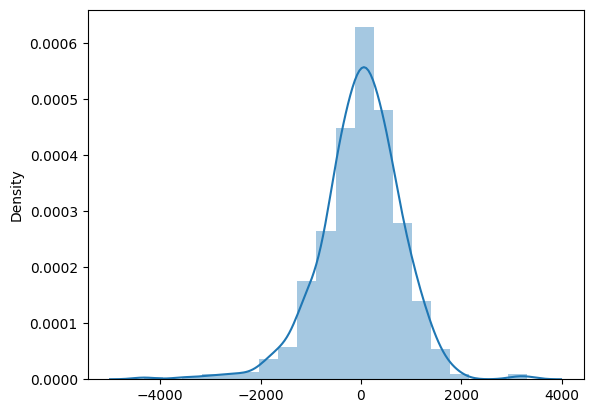

In [72]:
sns.distplot((y_train - y_train_pred), bins = 20)

In [73]:
x_test = sm.add_constant(x_test)

<Axes: ylabel='Density'>

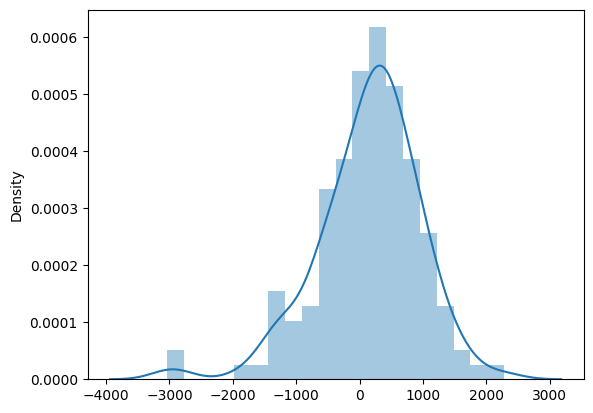

In [74]:
y_test_pred = lr. predict(x_test)

sns.distplot((y_test - y_test_pred), bins = 20)

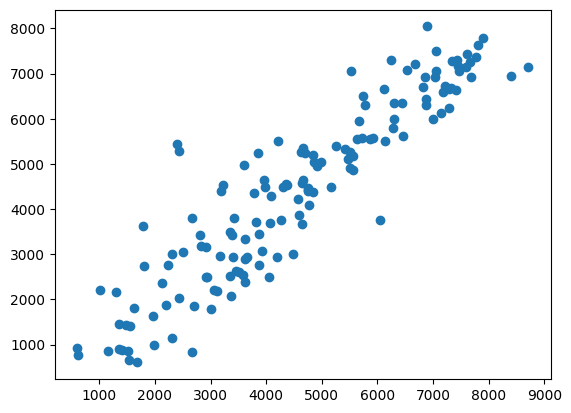

In [75]:
plt.scatter(y_test, y_test_pred)

In [76]:
from sklearn.metrics import mean_squared_error, r2_score

rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
rmse

np.float64(817.8570216481987)

In [79]:
r2 = r2_score(y_test, y_test_pred)
print(r2)

0.829277327375086


We have calculated the r2 score as above